# Clasificación binaria del abandono de clientes en telecomunicaciones

El objetivo de este trabajo es construir y comparar modelos de clasificación binaria para predecir la variable `Y`, que indica si un cliente abandona el servicio. El análisis se organiza en torno a dos enfoques principales: una selección de variables mediante RFE con regresión logística para optimizar una red neuronal en términos de Accuracy, y una selección de variables basada en árbol de decisión para optimizar una red neuronal en términos de Recall.

## Plan de trabajo

1. Carga y revisión inicial de los datos.
2. Análisis exploratorio y depuración.
3. Preparación metodológica: separación train/test y preprocesado.
4. Selección de variables mediante RFE y red neuronal orientada a Accuracy.
5. Selección de variables mediante árbol de decisión y red neuronal orientada a Recall.
6. Selección de thresholds y análisis de métricas.
7. Comparación global de modelos.
8. Conclusiones y preparación de resultados para la memoria.

## 1. Carga de librerías y datos

En esta sección se cargan las librerías básicas y la base de datos original. El objetivo es comprobar la estructura inicial del dataset antes de aplicar cualquier transformación.

In [99]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [62]:
ruta_datos = "../data/BBDD_ML_TAREA.csv"
df = pd.read_csv(ruta_datos)

In [63]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V12,V13,V14,V15,V16,V17,V18,V19,V20,Y
0,43,121,415.0,1118,0,0,0,86.1,100,14.64,...,113,22.08,148.0,79.0,6.66,9.1,9,2.46,2,0
1,7,170,510.0,3326,0,0,0,184.1,106,31.30,...,70,17.42,224.3,133.0,10.09,9.8,3,2.65,2,0
2,31,96,510.0,2146,0,0,0,150.0,122,25.50,...,116,18.57,212.4,89.0,9.56,9.8,1,2.65,3,0
3,17,90,415.0,387,0,0,0,193.7,83,32.93,...,79,13.11,299.0,60.0,13.46,12.7,3,3.43,1,0
4,7,61,415.0,313,0,0,0,140.6,89,23.90,...,128,14.69,212.4,97.0,9.56,13.6,4,3.67,1,0


In [64]:
df.shape

(9200, 21)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      9200 non-null   int64  
 1   V2      9200 non-null   int64  
 2   V3      9125 non-null   float64
 3   V4      9200 non-null   int64  
 4   V5      9200 non-null   int64  
 5   V6      9200 non-null   int64  
 6   V7      9200 non-null   int64  
 7   V8      9200 non-null   float64
 8   V9      9200 non-null   int64  
 9   V10     9174 non-null   float64
 10  V11     9200 non-null   float64
 11  V12     9200 non-null   int64  
 12  V13     9200 non-null   float64
 13  V14     9128 non-null   float64
 14  V15     9140 non-null   float64
 15  V16     9200 non-null   float64
 16  V17     9200 non-null   float64
 17  V18     9200 non-null   int64  
 18  V19     9156 non-null   float64
 19  V20     9200 non-null   int64  
 20  Y       9200 non-null   int64  
dtypes: float64(10), int64(11)
memory usag

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,9200.0,26.232391,14.697631,0.0,14.0000,26.00,39.0000,50.00
V2,9200.0,102.230326,40.065555,1.0,75.0000,102.00,128.0000,243.00
V3,9125.0,437.141370,42.320277,408.0,415.0000,415.00,510.0000,510.00
V4,9200.0,2512.690978,1438.955632,0.0,1253.0000,2536.50,3751.2500,4999.00
V5,9200.0,0.175326,0.380266,0.0,0.0000,0.00,0.0000,1.00
V6,9200.0,0.217826,0.412791,0.0,0.0000,0.00,0.0000,1.00
V7,9200.0,6.517826,12.872573,0.0,0.0000,0.00,0.0000,52.00
V8,9200.0,191.584424,61.523538,0.0,148.1000,189.30,236.7000,351.50
V9,9200.0,100.207826,20.247057,0.0,87.0000,100.00,114.0000,160.00
V10,9174.0,32.591252,10.458436,0.0,25.1825,32.20,40.2600,59.76


In [67]:
df["Y"].value_counts()

Y
0    4600
1    4600
Name: count, dtype: int64

### Observaciones iniciales

El conjunto de datos original contiene 9200 observaciones y 21 columnas: 20 variables explicativas (`V1` a `V20`) y una variable objetivo (`Y`). En la base original, la variable objetivo aparece balanceada, con el mismo número de observaciones en cada clase.

En esta fase no se aplica todavía ninguna transformación. Las decisiones de imputación, eliminación de variables, codificación o escalado se toman después de revisar nulos, duplicados, cardinalidades y posibles redundancias.

## 2. Análisis exploratorio y depuración

En esta sección se analiza la calidad del conjunto de datos antes del modelado. Se revisan valores perdidos, duplicados exactos, duplicados lógicos, variables identificativas, variables categóricas codificadas y redundancias entre predictores.

### 2.1 Valores perdidos

In [68]:
nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100
}).sort_values("n_nulos", ascending=False)

nulos[nulos["n_nulos"] > 0]

,n_nulos,porcentaje
V3,75,0.815217
V14,72,0.782609
V15,60,0.652174
V19,44,0.478261
V10,26,0.282609


Los valores perdidos afectan solo a algunas variables y, en todos los casos, el porcentaje observado es inferior al 1%. Por ello, no se eliminan variables en esta fase. El tratamiento definitivo de los nulos se realizará posteriormente dentro de los pipelines de preprocesado, ajustando la imputación únicamente con los datos de entrenamiento para evitar fuga de información.

### 2.2 Duplicados exactos

In [69]:
resumen_duplicados = pd.Series({
    "filas_originales": len(df),
    "duplicados_exactos": df.duplicated().sum(),
    "filas_en_grupos_duplicados": df.duplicated(keep=False).sum(),
    "filas_unicas": len(df.drop_duplicates())
})

resumen_duplicados

filas_originales              9200
duplicados_exactos            5662
filas_en_grupos_duplicados    7585
filas_unicas                  3538
dtype: int64

In [70]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V12,V13,V14,V15,V16,V17,V18,V19,V20,Y
118,0,1,408.0,2361,0,0,0,175.2,74,29.78,...,79,12.89,230.5,109.0,10.37,5.3,3,1.43,1,0
4255,0,1,408.0,2361,0,0,0,175.2,74,29.78,...,79,12.89,230.5,109.0,10.37,5.3,3,1.43,1,0
5665,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
5707,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
5797,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
5842,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
6710,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
7162,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
7349,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1
7915,0,36,415.0,3736,1,1,19,171.9,96,29.22,...,111,16.86,321.7,76.0,14.48,10.5,1,2.84,1,1


In [71]:
df_unico = df.drop_duplicates().reset_index(drop=True)

In [72]:
pd.DataFrame({
    "original": df["Y"].value_counts().sort_index(),
    "sin_duplicados_exactos": df_unico["Y"].value_counts().sort_index()
})

,original,sin_duplicados_exactos
Y,,
0,4600,2832
1,4600,706


Se detecta un número elevado de duplicados exactos en la base original. Mantener copias idénticas antes de la partición train/test podría provocar que una misma observación apareciera simultáneamente en entrenamiento y prueba, generando una evaluación optimista.

Por este motivo, se crea `df_unico`, una versión sin duplicados exactos. Tras esta depuración, la distribución de la variable objetivo deja de estar balanceada, lo que sugiere que las repeticiones afectaban especialmente a la clase positiva.

### 2.3 Duplicados lógicos asociados a `V4`

In [73]:
duplicados_v4 = df_unico[df_unico["V4"].duplicated(keep=False)].sort_values("V4")
duplicados_v4

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V12,V13,V14,V15,V16,V17,V18,V19,V20,Y
515,47,238,415.0,1251,0,0,0,202.0,60,34.34,...,105,18.18,266.4,90.0,11.99,12.0,1,3.24,2,0
2592,47,238,415.0,1251,0,0,0,202.0,60,34.34,...,105,18.18,NaN,90.0,11.99,12.0,1,3.24,2,0
3287,27,95,NaN,2943,0,0,0,128.6,115,21.86,...,88,18.38,255.3,96.0,11.49,6.3,2,1.70,6,1
3502,27,95,408.0,2943,0,0,0,128.6,115,21.86,...,88,18.38,255.3,96.0,11.49,6.3,2,1.70,6,1


In [74]:
duplicados_v4.assign(n_nulos=duplicados_v4.isna().sum(axis=1))

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V13,V14,V15,V16,V17,V18,V19,V20,Y,n_nulos
515,47,238,415.0,1251,0,0,0,202.0,60,34.34,...,18.18,266.4,90.0,11.99,12.0,1,3.24,2,0,0
2592,47,238,415.0,1251,0,0,0,202.0,60,34.34,...,18.18,NaN,90.0,11.99,12.0,1,3.24,2,0,1
3287,27,95,NaN,2943,0,0,0,128.6,115,21.86,...,18.38,255.3,96.0,11.49,6.3,2,1.70,6,1,1
3502,27,95,408.0,2943,0,0,0,128.6,115,21.86,...,18.38,255.3,96.0,11.49,6.3,2,1.70,6,1,0


In [75]:
df_limpio = (
    df_unico
    .assign(n_nulos=df_unico.isna().sum(axis=1))
    .sort_values(["V4", "n_nulos"])
    .drop_duplicates(subset="V4", keep="first")
    .drop(columns="n_nulos")
    .reset_index(drop=True)
)

In [76]:
resumen_df_limpio = pd.Series({
    "filas": df_limpio.shape[0],
    "columnas": df_limpio.shape[1],
    "duplicados_v4": df_limpio["V4"].duplicated().sum()
})

resumen_df_limpio

filas            3536
columnas           21
duplicados_v4       0
dtype: int64

In [77]:
df_limpio["Y"].value_counts()

Y
0    2831
1     705
Name: count, dtype: int64

In [78]:
df_limpio["Y"].value_counts(normalize=True)

Y
0    0.800622
1    0.199378
Name: proportion, dtype: float64

Después de eliminar duplicados exactos, se revisan los identificadores `V4` repetidos. Los casos restantes corresponden a registros equivalentes en los que una de las filas contiene algún valor perdido adicional. Para cada `V4` repetido se conserva la fila con menor número de nulos, eliminando la versión parcial.

A partir de este punto, `df_limpio` se considera la base depurada de referencia. La variable `V4` se ha usado para detectar duplicados, pero no se utilizará como predictor porque representa un identificador del cliente.

### 2.4 Clasificación metodológica de variables

In [79]:
variable_objetivo = "Y"

variables_identificativas = ["V4"]
variables_categoricas_codificadas = ["V1", "V3"]
variables_binarias = ["V5", "V6"]
variables_numericas = [
    "V2", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15",
    "V16", "V17", "V18", "V19", "V20"
]

variables_clasificadas = (
    variables_identificativas
    + variables_categoricas_codificadas
    + variables_binarias
    + variables_numericas
    + [variable_objetivo]
)

set(df_limpio.columns) - set(variables_clasificadas), set(variables_clasificadas) - set(df_limpio.columns)

(set(), set())

Aunque todas las variables están almacenadas numéricamente, no todas tienen la misma naturaleza estadística. `V4` es una variable identificativa y se excluirá del modelado. `V1` y `V3` representan categorías codificadas mediante números, por lo que se transformarán mediante variables dummy en los pipelines de modelado. Esta decisión evita imponer una relación ordinal artificial tanto en modelos lineales como en árboles de decisión.

Las variables `V5` y `V6` son binarias, mientras que el resto de predictores describen antigüedad, consumo, número de llamadas, costes y llamadas al servicio de atención.

### 2.5 Redundancia entre variables de minutos y coste

In [80]:
pares_redundantes = [
    ("V8", "V10"),   # minutos diurnos y coste diurno
    ("V11", "V13"), # minutos vespertinos y coste vespertino
    ("V14", "V16"), # minutos nocturnos y coste nocturno
    ("V17", "V19")  # minutos internacionales y coste internacional
]

for var_minutos, var_coste in pares_redundantes:
    correlacion = df_limpio[[var_minutos, var_coste]].corr().iloc[0, 1]
    print(f"{var_minutos}-{var_coste}: {correlacion:.6f}")

V8-V10: 1.000000
V11-V13: 1.000000
V14-V16: 0.999999
V17-V19: 0.999993


In [81]:
variables_minutos_costes = [
    "V8", "V10", "V11", "V13",
    "V14", "V16", "V17", "V19"
]

df_limpio[variables_minutos_costes].corr()

,V8,V10,V11,V13,V14,V16,V17,V19
V8,1.000000,1.000000,0.021484,0.021472,0.029889,0.027777,-0.011860,-0.012919
V10,1.000000,1.000000,0.020156,0.020144,0.030935,0.028803,-0.011742,-0.012812
V11,0.021484,0.020156,1.000000,1.000000,-0.012791,-0.013678,-0.013561,-0.013724
V13,0.021472,0.020144,1.000000,1.000000,-0.012797,-0.013684,-0.013565,-0.013727
V14,0.029889,0.030935,-0.012791,-0.012797,1.000000,0.999999,-0.003670,-0.002634
V16,0.027777,0.028803,-0.013678,-0.013684,0.999999,1.000000,-0.003400,-0.002376
V17,-0.011860,-0.011742,-0.013561,-0.013565,-0.003670,-0.003400,1.000000,0.999993
V19,-0.012919,-0.012812,-0.013724,-0.013727,-0.002634,-0.002376,0.999993,1.000000


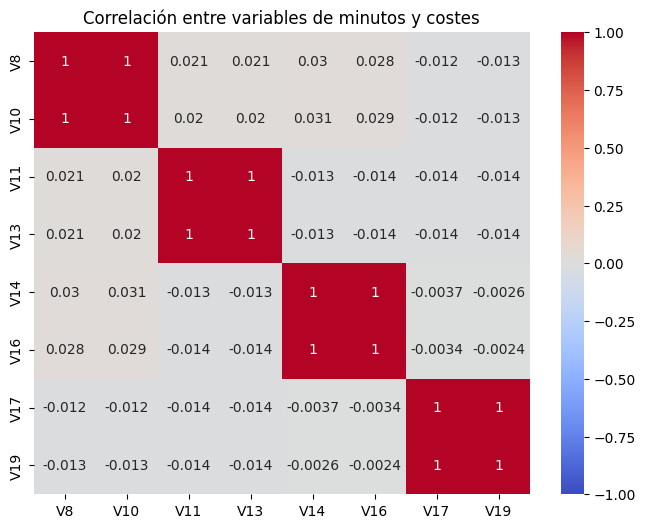

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_limpio[variables_minutos_costes].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlación entre variables de minutos y costes")
plt.show()

Las variables de coste (`V10`, `V13`, `V16` y `V19`) presentan una correlación prácticamente perfecta con sus correspondientes variables de minutos (`V8`, `V11`, `V14` y `V17`). Esto indica que aportan información casi equivalente, probablemente porque el coste se deriva directamente de los minutos consumidos.

Para reducir redundancia y mejorar la estabilidad de los procesos de selección de variables, se conservarán las variables de minutos y se excluirán las variables de coste en los pipelines posteriores. Esta decisión también facilita la interpretación de las importancias en árboles de decisión, evitando repartir importancia entre predictores prácticamente equivalentes.

### 2.6 Base preparada para modelado

In [83]:
variables_coste_redundantes = ["V10", "V13", "V16", "V19"]
variables_excluidas = variables_identificativas + variables_coste_redundantes

df_modelado = df_limpio.drop(columns=variables_excluidas)

In [84]:
df_modelado.shape

(3536, 16)

In [87]:
df_modelado.columns.tolist()

['V1',
 'V2',
 'V3',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V11',
 'V12',
 'V14',
 'V15',
 'V17',
 'V18',
 'V20',
 'Y']

In [88]:
df_modelado.isna().sum()[df_modelado.isna().sum() > 0]

V3     34
V14    25
V15    28
dtype: int64

La base `df_modelado` conserva la información necesaria para el modelado y excluye las variables identificativas o redundantes. Los valores perdidos restantes no se imputan todavía: se tratarán dentro de los pipelines después de separar entrenamiento y prueba, evitando utilizar información del conjunto de test durante el preprocesado.

## 3. Preparación metodológica antes del modelado

En esta sección se define la separación entre variables explicativas y variable objetivo, así como la partición entre entrenamiento y prueba. También se establece el preprocesado que se aplicará posteriormente dentro de pipelines, evitando ajustar transformaciones sobre el conjunto completo de datos.


### 3.1 Separación entre variables explicativas y objetivo


In [89]:
X = df_modelado.drop(columns="Y")
y = df_modelado["Y"]

In [90]:
X.shape, y.shape

((3536, 15), (3536,))

In [91]:
y.value_counts(normalize=True)

Y
0    0.800622
1    0.199378
Name: proportion, dtype: float64

La variable objetivo se separa antes de cualquier transformación de predictores. La distribución de `Y` se mantiene desbalanceada tras la depuración, por lo que la partición train/test deberá ser estratificada para conservar proporciones similares de clases en ambos conjuntos.


### 3.2 Partición train/test estratificada


In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    stratify=y,
    random_state=21
)

In [94]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((2828, 15), (708, 15), (2828,), (708,))

In [95]:
pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True)
}).sort_index()


,train,test
Y,,
0,0.800566,0.800847
1,0.199434,0.199153


### 3.3 Definición del preprocesado


In [96]:
variables_categoricas = ["V1", "V3"]

variables_binarias = ["V5", "V6"]

variables_numericas_modelado = [
    "V2", "V7", "V8", "V9",
    "V11", "V12", "V14", "V15",
    "V17", "V18", "V20"
]


In [97]:
variables_preprocesado = (
    variables_categoricas
    + variables_binarias
    + variables_numericas_modelado
)

set(X.columns) - set(variables_preprocesado), set(variables_preprocesado) - set(X.columns)


(set(), set())

In [101]:
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")) 
    ])

transformador_numerico_escalado = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_numerico_sin_escalar = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy = "median"))
])

transformador_binario = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

In [102]:
preprocesador_lineal_nn = ColumnTransformer(
    transformers=[
        ("cat", transformador_categorico, variables_categoricas),
        ("bin", transformador_binario, variables_binarias),
        ("num", transformador_numerico_escalado, variables_numericas_modelado)
    ]
)

In [103]:
preprocesador_arbol = ColumnTransformer(
    transformers=[
        ("cat", transformador_categorico, variables_categoricas),
        ("bin", transformador_binario, variables_binarias),
        ("num", transformador_numerico_sin_escalar, variables_numericas_modelado)
    ]
)


Se definen dos esquemas de preprocesado. Para la regresión logística y las redes neuronales se aplica imputación, codificación mediante variables dummy y escalado de variables numéricas. El escalado es necesario porque estos modelos son sensibles a la escala de los predictores.

Para el árbol de decisión se mantiene la imputación y la codificación dummy de variables categóricas, pero no se aplica escalado, ya que los árboles no dependen de distancias ni de coeficientes lineales. En ambos casos, las transformaciones se integrarán dentro de pipelines para que se ajusten únicamente con los datos de entrenamiento.
